<a href="https://colab.research.google.com/github/djibrillaseydouhamadou/Niamey-Manure-Valorization-Chain/blob/main/Eleveur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTER LES PACKAGES NECESSAIRES
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd



In [2]:
# LIRE LA BASE DE DONNÉES
df = pd.read_csv('/content/Fiche_eleveur.csv', encoding='latin1', delimiter=';')

In [3]:
# NETTOYAGE DES NOMS DE COLONNES ET DES DONNÉES
def clean_text(text):
    if isinstance(text, str):
        return text.replace('\u008e', 'é').replace('\u0088', 'à').replace('\u008f', 'e').replace('\u008d', 'ç').replace('\u00a1', '°').strip()
    return text

# Nettoyage des colonnes
df.columns = [clean_text(col) for col in df.columns]

# Nettoyage des données (toutes les colonnes de type objet/string)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(clean_text)

print("Variables et données nettoyées.")
display(df.columns.tolist())

Variables et données nettoyées.


['Numéro de fiche',
 'Region',
 'Arrondissement communal (Niamey)',
 'Marché à betail de',
 'Coodonnéess',
 "Date de l'enqueté",
 'Nom et Prénom du chef du marché',
 "Contact de l'enqueté",
 'Age',
 'Etat matrimonial',
 "Niveau d'instruction",
 'Taille du ménage',
 "Nombre d'enfants",
 "Chef d'exploitation",
 'Activité principale',
 'Activités secondaire',
 "Types d'animaux concernés",
 "Types des systeme d'élevage pratiqué",
 'Principaux acheteurs des animaux',
 'Facteurs influençant la variation des prix',
 "Mode d'acquisition des animaux",
 'Mode de transport des animaux vers les marchés',
 'Mode de collecte du fumier dans les enclos',
 'comment se passe le stockage du fumier dans les marchés ?',
 'Prix moyenne de la vente du fumier (Sac/Tas/Véhicule)',
 "Princiapaux contraintes observées lors de l'embouche animal?",
 'Principaux problemes rencontrés lors de la vente des animaux?',
 "Pistes d'amélioration proposées?"]

### Statistiques Descriptives par Marché
Calcul des indicateurs clés (moyenne, médiane, etc.) pour les variables numériques groupées par la colonne `Marché à betail de`.

In [4]:
# Correction des doublons de noms de marchés et calcul des statistiques

# 1. Harmonisation du nom du marché
# On corrige 'Touakou Aéroport' en 'Tourakou Aéroport'
df['Marché à betail de'] = df['Marché à betail de'].replace('Touakou Aéroport', 'Tourakou Aéroport')

# 2. Calcul des statistiques descriptives
cols_to_exclude = ['Numéro de fiche', 'Arrondissement communal (Niamey)']
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
relevant_cols = [col for col in numeric_cols if col not in cols_to_exclude]

group_col = 'Marché à betail de'

if group_col in df.columns:
    stats_par_marche = df.groupby(group_col)[relevant_cols].describe()
    display(stats_par_marche)
else:
    print(f"La colonne '{group_col}' est introuvable.")

Age                                                  \
                     count       mean        std   min    25%   50%    75%   
Marché à betail de                                                           
Grand Tourakou (K.D)   6.0  49.500000  18.555323  28.0  34.25  49.0  63.75   
Tourakou Aéroport      7.0  48.428571   8.866738  39.0  42.50  47.0  52.50   
Tourakou Harobanda    10.0  47.900000  11.229426  34.0  41.25  45.0  56.75   
Tourakou Niamey 2000   8.0  57.250000  17.044061  28.0  46.75  57.0  70.75   
Tourakou Talladjé      7.0  37.428571  10.580755  18.0  34.50  40.0  42.50   
Tourakou échangeur     1.0  45.000000        NaN  45.0  45.00  45.0  45.00   

                           Taille du ménage             ...              \
                       max            count       mean  ...   75%   max   
Marché à betail de                                      ...               
Grand Tourakou (K.D)  73.0              6.0  10.000000  ...  13.0  19.0   
Tourakou Aéroport     63.0              7.0  10.714286  ...  14.5  21.0   
Tourakou Harobanda    65.0             10.0   6.700000  ...   7.0  12.0   
Tourakou Niamey 2000  80.0              8.0  12.625000  ...  12.0  41.0   
Tourakou Talladjé     50.0              7.0   9.428571  ...  15.5  21.0   
Tourakou échangeur    45.0              1.0  18.000000  ...  18.0  18.0   

                     Nombre d'enfants                                     \
                                count       mean        std   min    25%   
Marché à betail de                                                         
Grand Tourakou (K.D)              6.0   7.500000   4.929503   2.0   3.75   
Tourakou Aéroport                 7.0   8.000000   5.802298   2.0   3.50   
Tourakou Harobanda               10.0   4.600000   2.458545   1.0   3.25   
Tourakou Niamey 2000              8.0  10.125000  11.728323   1.0   5.00   
Tourakou Talladjé                 7.0   7.428571   7.067700   0.0   1.50   
Tourakou échangeur                1.0  14.000000        NaN  14.0  14.00   

                                         
                       50%    75%   max  
Marché à betail de                       
Grand Tourakou (K.D)   7.0  10.25  15.0  
Tourakou Aéroport      6.0  12.00  17.0  
Tourakou Harobanda     5.0   5.00  10.0  
Tourakou Niamey 2000   7.5   9.25  38.0  
Tourakou Talladjé      6.0  12.50  18.0  
Tourakou échangeur    14.0  14.00  14.0  

[6 rows x 24 columns]

Âge des Éleveurs :

Le marché Tourakou Niamey 2000 attire les éleveurs les plus âgés avec une moyenne de 57,2 ans. C'est aussi là que l'on trouve le doyen de votre étude (80 ans).
Le marché Tourakou Talladjé se distingue par une population beaucoup plus jeune, avec une moyenne de 37,4 ans et le plus jeune profil de l'échantillon (18 ans).
Taille du Ménage :

On observe des disparités sociales importantes. À Tourakou Niamey 2000, la taille moyenne du ménage est la plus élevée (12,6 personnes), avec des structures familiales pouvant atteindre 41 personnes.
À l'inverse, Tourakou Harobanda présente les ménages les plus restreints avec une moyenne de 6,7 personnes.
Nombre d'Enfants :

La moyenne du nombre d'enfants suit généralement la taille des ménages. Elle est la plus forte à Tourakou échangeur (14 enfants - bien que basé sur un seul individu) et à Tourakou Niamey 2000 (10,1 enfants).
On note une forte variabilité (écart-type élevé) à Niamey 2000, ce qui signifie que les profils de familles y sont très diversifiés.
Précision Statistique :

Pour les marchés comme Tourakou échangeur et Tourakou Aéroport (partie unique), l'écart-type (std) est NaN. Cela indique que vous n'avez qu'une seule observation pour ces groupes, ce qui ne permet pas de mesurer la dispersion.
Cette analyse suggère que le profil socio-démographique des éleveurs varie sensiblement selon le marché fréquenté, ce qui pourrait influencer leurs pratiques ou leurs besoins en termes d'appui à l'élevage.

### Tableau de Bord : Profil Socio-économique par Marché (Barres Empilées %)

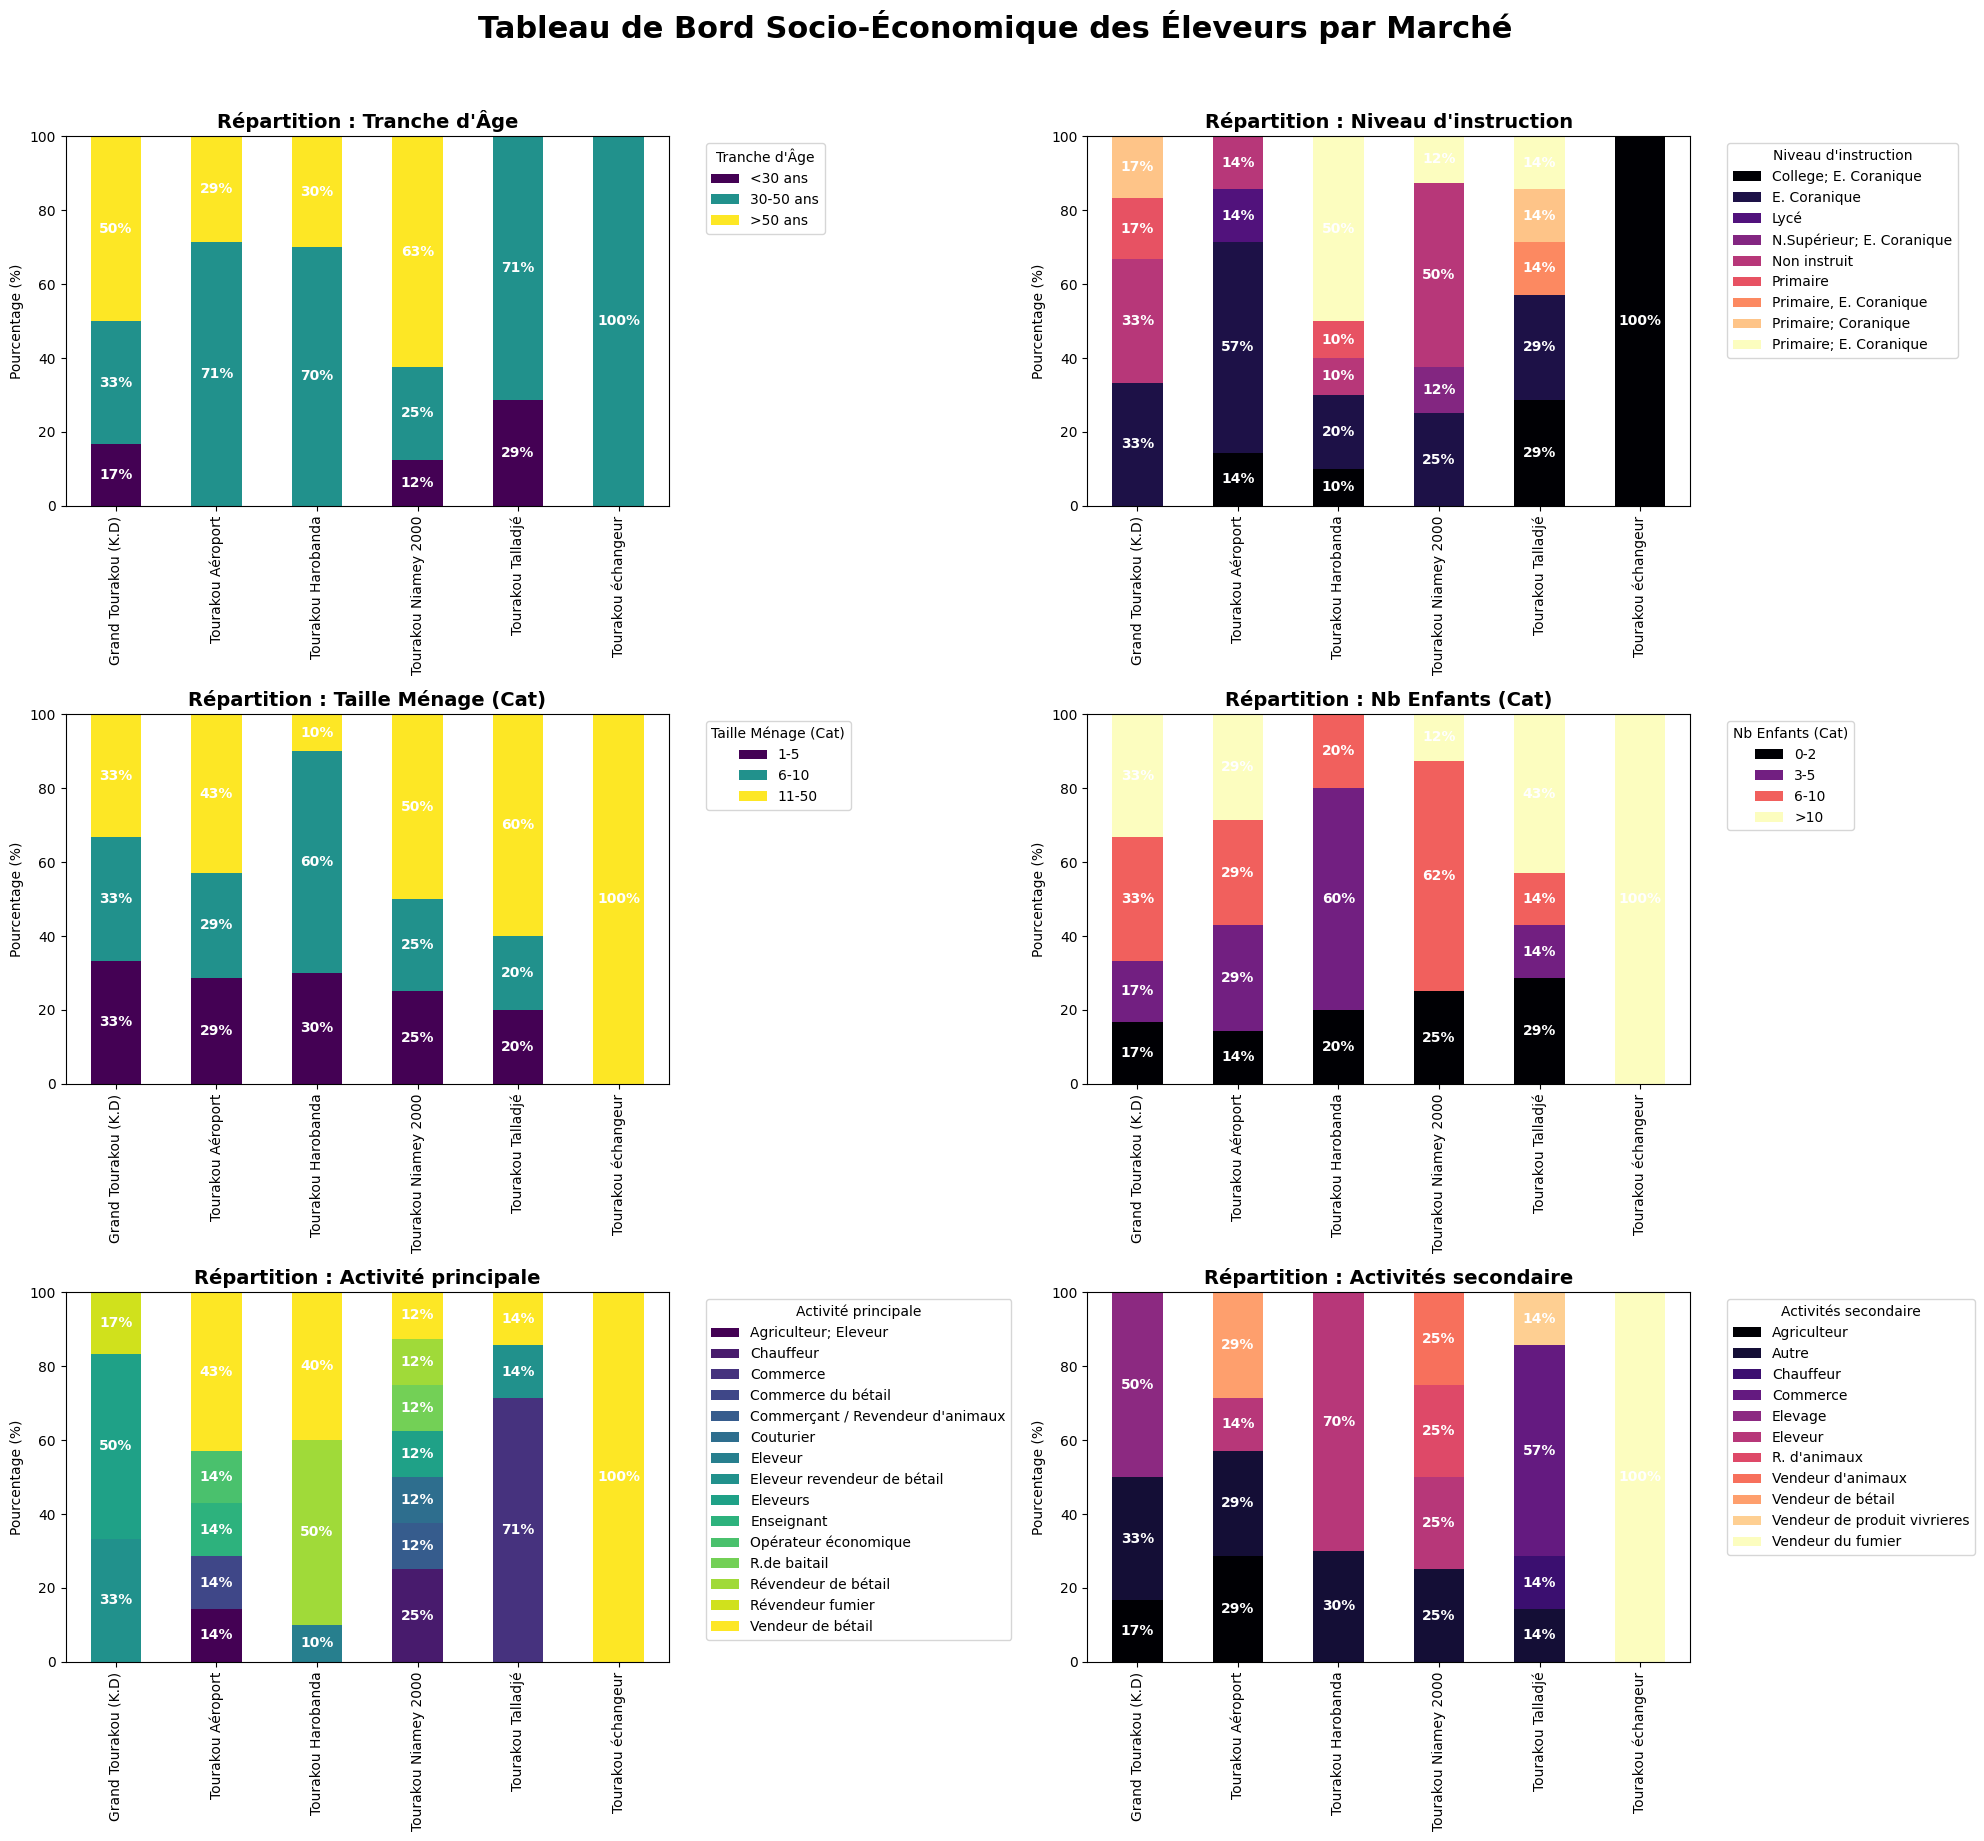

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Préparation des données
df_plot = df.copy()
df_plot['Tranche d\'Âge'] = pd.cut(df_plot['Age'], bins=[0, 30, 50, 100], labels=['<30 ans', '30-50 ans', '>50 ans'])
df_plot['Taille Ménage (Cat)'] = pd.cut(df_plot['Taille du ménage'], bins=[0, 5, 10, 50, 100], labels=['1-5', '6-10', '11-50', '>50'])
df_plot['Nb Enfants (Cat)'] = pd.cut(df_plot['Nombre d\'enfants'], bins=[-1, 2, 5, 10, 50], labels=['0-2', '3-5', '6-10', '>10'])

vars_to_plot = [
    'Tranche d\'Âge', "Niveau d'instruction", 'Taille Ménage (Cat)',
    'Nb Enfants (Cat)', 'Activité principale', 'Activités secondaire'
]

# Configuration de la grille (2 colonnes)
n_cols = 2
n_rows = math.ceil(len(vars_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
fig.suptitle("Tableau de Bord Socio-Économique des Éleveurs par Marché", fontsize=22, fontweight='bold', y=1.02)

market_col = 'Marché à betail de'
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ct = pd.crosstab(df_plot[market_col], df_plot[var], normalize='index') * 100

    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis' if i%2==0 else 'magma')

    axes[i].set_title(f"Répartition : {var}", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Pourcentage (%)")
    axes[i].set_xlabel("")
    axes[i].legend(title=var, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[i].set_ylim(0, 100)

    for p in axes[i].patches:
        width, height = p.get_width(), p.get_height()
        if height > 5:
            axes[i].annotate(f'{height:.0f}%', (p.get_x() + width/2, p.get_y() + height/2),
                             ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# Supprimer les axes vides si le nombre de variables est impair
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interprétation Détaillée du Tableau de Bord Socio-économique

Ce tableau de bord permet de dresser un portrait contrasté des éleveurs selon leur marché d'attache :

#### 1. Profil Démographique (Âge et Éducation)
*   **Âge** : On observe une dualité nette. Le marché de **Tourakou Niamey 2000** est dominé par des éleveurs seniors (>50 ans), suggérant une activité gérée par des chefs de famille expérimentés. À l'opposé, **Tourakou Talladjé** affiche une forte proportion de jeunes (<30 ans), indiquant un renouvellement de la main-d'œuvre ou une entrée précoce dans la filière.
*   **Instruction** : Le niveau d'instruction varie fortement. Les marchés urbains ou semi-urbains montrent une mixité entre l'école coranique et le primaire/secondaire, mais une part importante d'éleveurs reste sans instruction formelle, ce qui peut influencer l'adoption de nouvelles techniques d'embouche.

#### 2. Structure Familiale
*   **Taille du Ménage & Enfants** : Les marchés comme **Niamey 2000** et **Tourakou échangeur** se distinguent par des familles très nombreuses (souvent >10 enfants et >11 personnes au total). Cela implique une forte charge sociale, mais aussi une disponibilité potentielle de main-d'œuvre familiale pour l'entretien du bétail.

#### 3. Dynamique des Activités
*   **Activité Principale** : L'élevage et le commerce dominent, mais certains marchés montrent une spécialisation plus marquée dans le commerce de bétail pur, tandis que d'autres conservent un lien fort avec l'agriculture.
*   **Activités Secondaires** : La diversification est la règle. Beaucoup d'éleveurs complètent leurs revenus par le petit commerce ou l'agriculture. Cette pluriactivité est une stratégie de résilience face aux risques liés à l'élevage (maladies, fluctuation des prix).

**Note de synthèse** : Le profil type varie de l'éleveur-commerçant âgé et chef d'une grande famille à Niamey 2000, au jeune éleveur plus mobile de Talladjé. Ces différences doivent être prises en compte pour toute recommandation de politique publique ou de projet de développement.

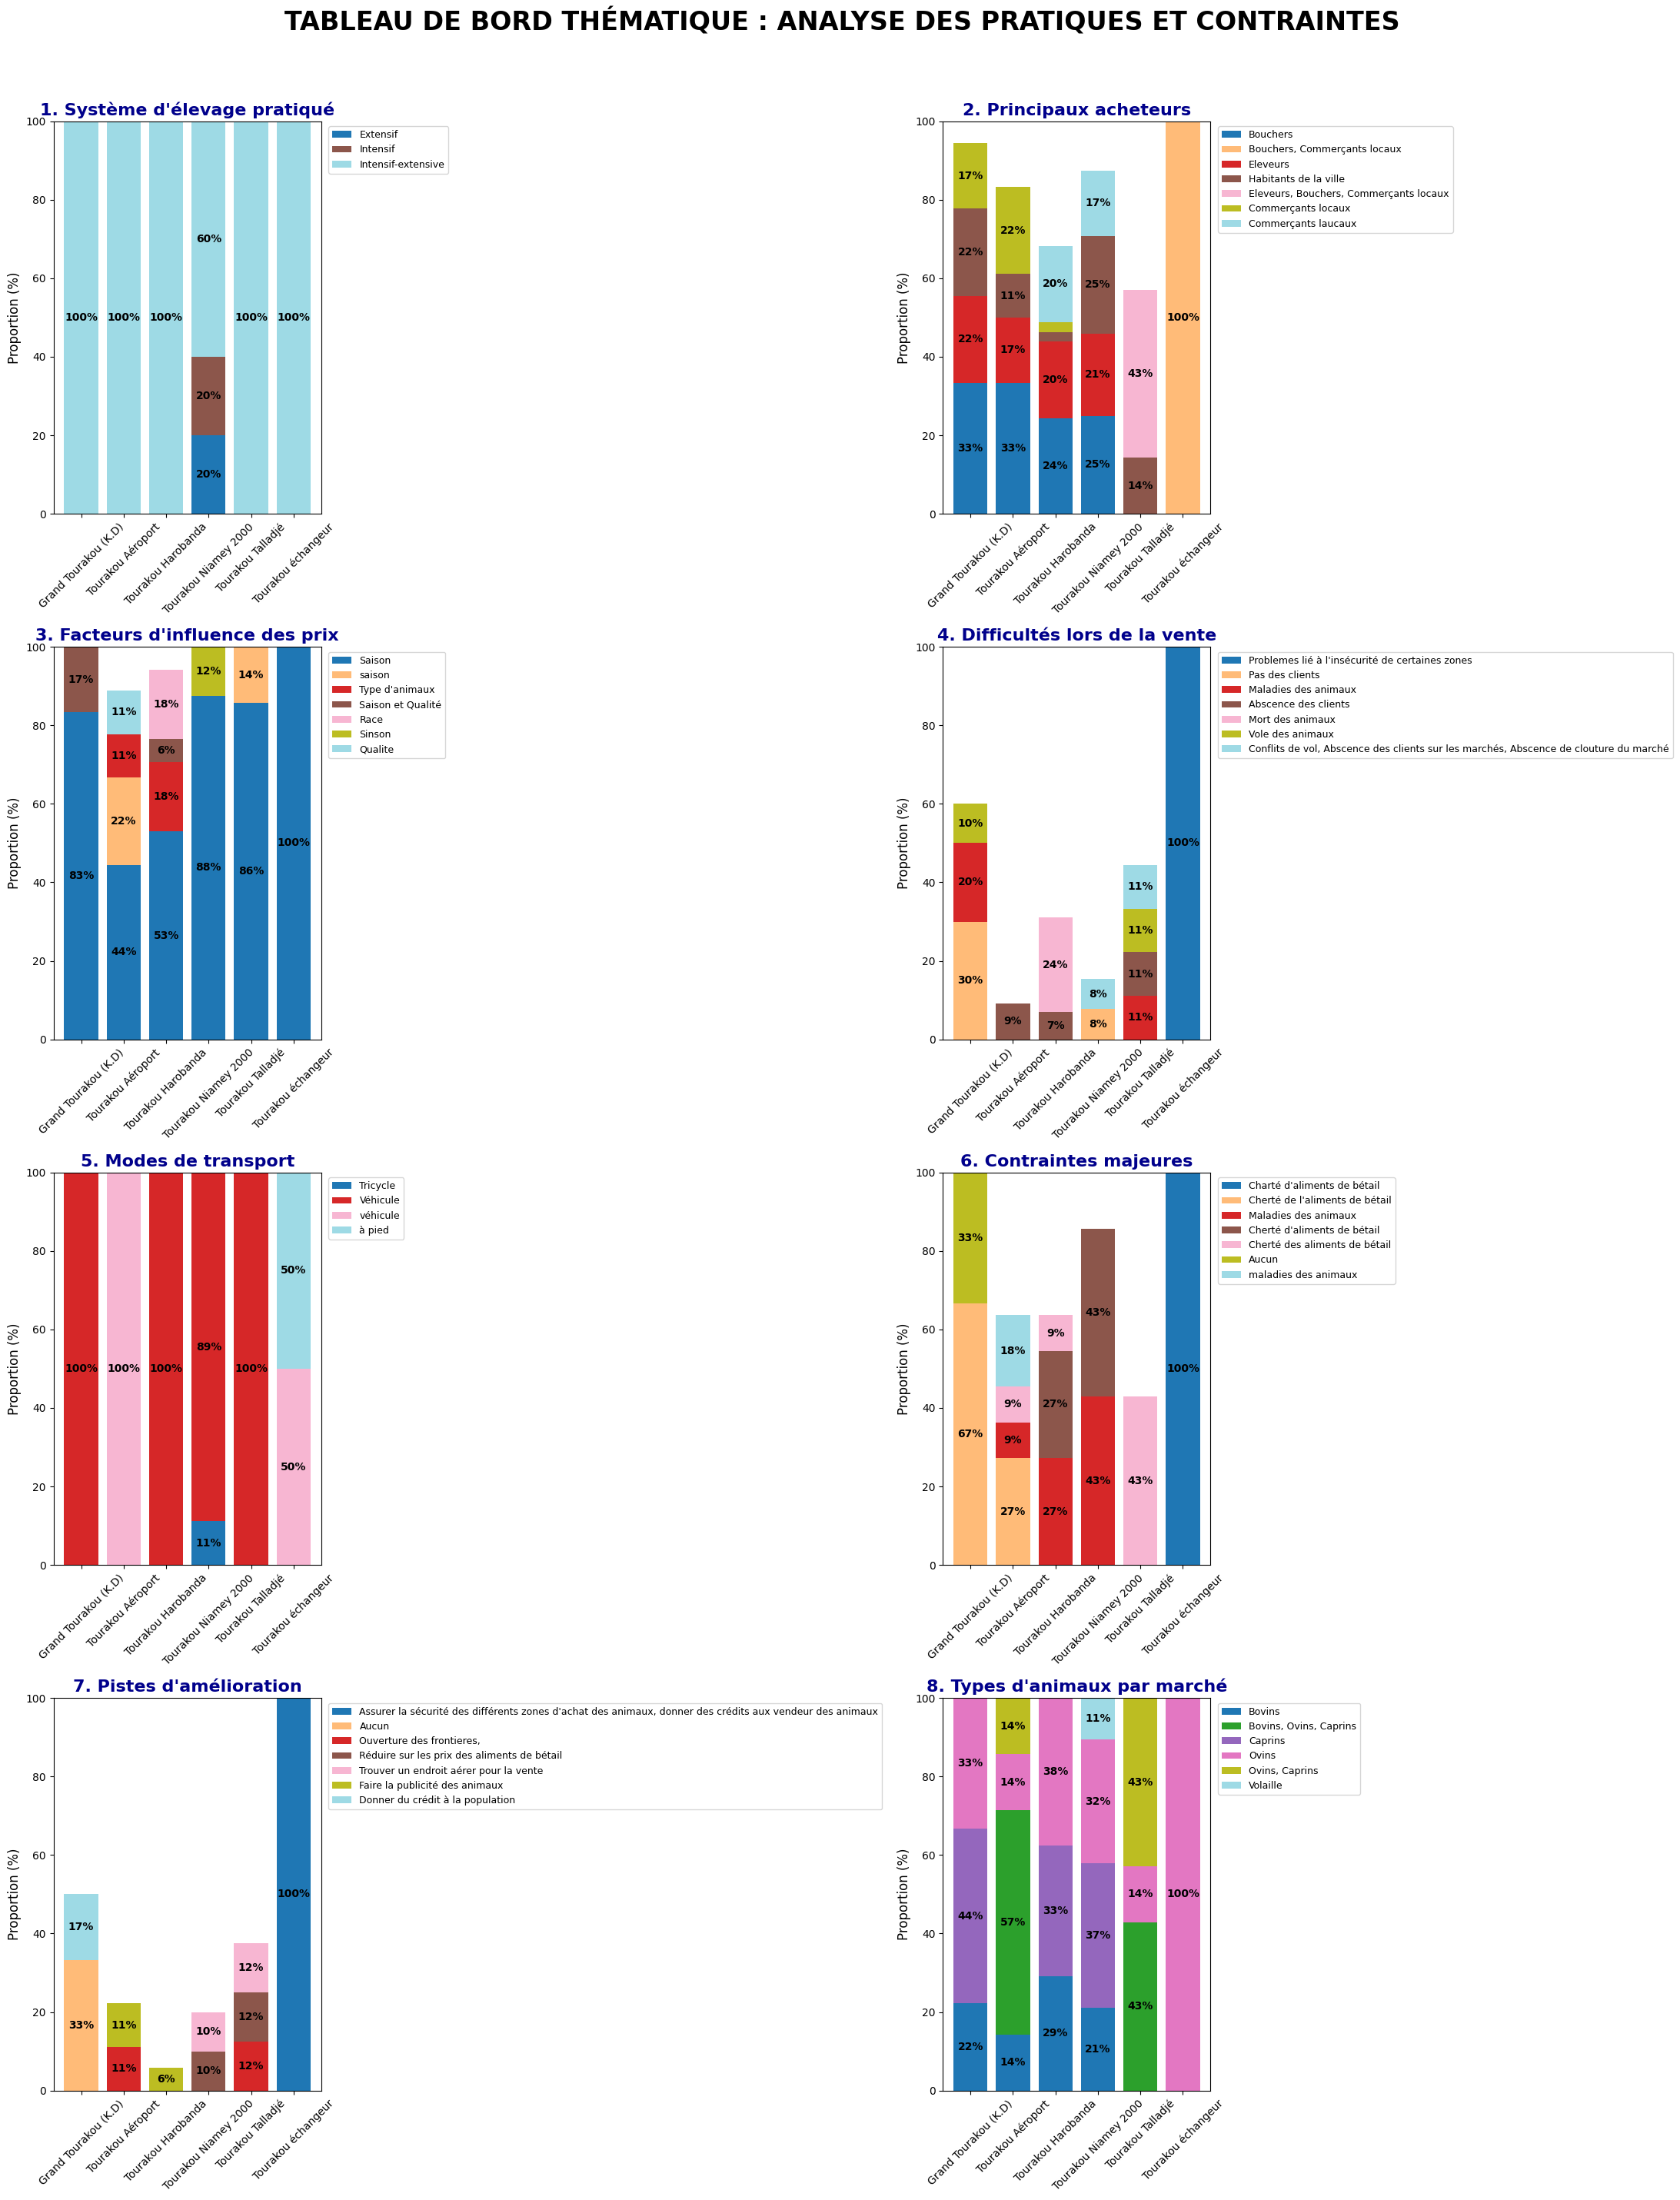

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import math

# 1. Identification et Nettoyage
col_problemes_vente = df.columns[-2]
col_animaux = "Types d'animaux concernés"

theme_mapping = [
    ("systeme", "Système d'élevage pratiqué"),
    ("acheteur", "Principaux acheteurs"),
    ("facteur", "Facteurs d'influence des prix"),
    (col_problemes_vente, "Difficultés lors de la vente"),
    ("transport", "Modes de transport"),
    ("contrainte", "Contraintes majeures"),
    ("amélioration", "Pistes d'amélioration"),
    (col_animaux, "Types d'animaux par marché")
]

def clean_and_split(text):
    if not isinstance(text, str): return ["N/A"]
    t = text.replace("Charété", "Cherté").replace("charté", "Cherté").replace("aliment de bétail", "aliments de bétail")
    t = ''.join([c for c in t if ord(c) < 128 or c in "éèàâêîïôûùçÉÀÈ"])
    parts = [p.strip() for p in t.split(';') if p.strip()]
    return parts if parts else ["N/A"]

selected_vars = []
all_cols = df.columns.tolist()
for key, title in theme_mapping:
    if key in all_cols: selected_vars.append((key, title))
    else:
        for col in all_cols:
            if key.lower() in col.lower() and "fumier" not in col.lower():
                if col not in [v[0] for v in selected_vars]:
                    selected_vars.append((col, title))
                    break

# 2. Génération du Dashboard (Pareil au premier : Grille 2 colonnes, Barres Verticales)
n_vars = len(selected_vars)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 7 * n_rows))
fig.suptitle("TABLEAU DE BORD THÉMATIQUE : ANALYSE DES PRATIQUES ET CONTRAINTES", fontsize=24, fontweight='bold', y=1.02)

market_col = 'Marché à betail de'
axes_flat = axes.flatten()

for i, (col_name, title) in enumerate(selected_vars):
    temp_df = df[[market_col, col_name]].copy()
    temp_df[col_name] = temp_df[col_name].apply(clean_and_split)
    temp_exploded = temp_df.explode(col_name)

    ct = pd.crosstab(temp_exploded[market_col], temp_exploded[col_name], normalize='index') * 100

    if ct.shape[1] > 7:
        top_cols = ct.sum().nlargest(7).index
        ct = ct[top_cols]

    # kind='bar' (vertical) pour être pareil au premier tableau
    ct.plot(kind='bar', stacked=True, ax=axes_flat[i], colormap='tab20', width=0.8)

    axes_flat[i].set_title(f"{i+1}. {title}", fontsize=16, fontweight='bold', color='darkblue')
    axes_flat[i].set_ylabel("Proportion (%)", fontsize=12)
    axes_flat[i].set_xlabel("", fontsize=12)
    axes_flat[i].tick_params(axis='x', rotation=45, labelsize=10)
    axes_flat[i].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    axes_flat[i].set_ylim(0, 100)

    # Annotation des pourcentages
    for p in axes_flat[i].patches:
        h = p.get_height()
        if h > 5:
            axes_flat[i].annotate(f'{h:.0f}%',
                                 (p.get_x() + p.get_width()/2, p.get_y() + h/2),
                                 ha='center', va='center', color='black',
                                 fontsize=10, fontweight='bold')

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

Organisation des Systèmes et Types d'Animaux
Système d'élevage : L'embouche intensive et semi-intensive domine largement. Cela indique une professionnalisation de l'activité tournée vers la finition rapide des animaux pour répondre à la demande urbaine.
Spécialisation par marché : On note une forte présence des Bovins à Niamey 2000 et de l'échangeur, tandis que les marchés comme Tourakou Aéroport ou Harobanda présentent une plus grande diversité incluant Ovins et Caprins.
2. Dynamique Commerciale et Prix
Principaux acheteurs : Le circuit est dominé par les commerçants locaux et les bouchers. L'absence quasi-totale d'exportateurs directs dans certaines zones suggère que les éleveurs dépendent de collecteurs intermédiaires.
Fluctuation des prix : La Tabaski est le facteur d'influence n°1. Les prix ne sont pas indexés sur la qualité intrinsèque seule, mais sur le calendrier religieux, créant une forte saisonnalité des revenus.
3. Logistique et Vente
Modes de transport : Le transport par camion et véhicule léger remplace progressivement la marche à pied, surtout pour l'approvisionnement des marchés périphériques vers le centre-ville.
Difficultés de vente : Les éleveurs rapportent l'instabilité des prix et le poids des intermédiaires (Dillali) comme des freins majeurs à l'obtention d'un prix juste.
4. Contraintes Majeures et Leviers d'Amélioration
Le nœud du problème (Aliments) : La cherté des aliments de bétail est citée de manière quasi unanime (souvent >80% des citations). C'est le premier facteur limitant la rentabilité.
Solutions préconisées : Les éleveurs ne demandent pas seulement des subventions, mais surtout un meilleur accès au crédit pour financer l'achat de bétail et d'aliments, ainsi qu'un renforcement de la couverture vétérinaire pour protéger leur capital.
Cette analyse montre que si l'élevage est une activité structurellement forte à Niamey, elle reste vulnérable à la volatilité des coûts de production.

### 4. Analyse Typologique : Classification Hiérarchique Ascendante (CHA)
L'objectif est d'identifier des groupes d'éleveurs homogènes basés sur leurs caractéristiques socio-économiques et techniques.

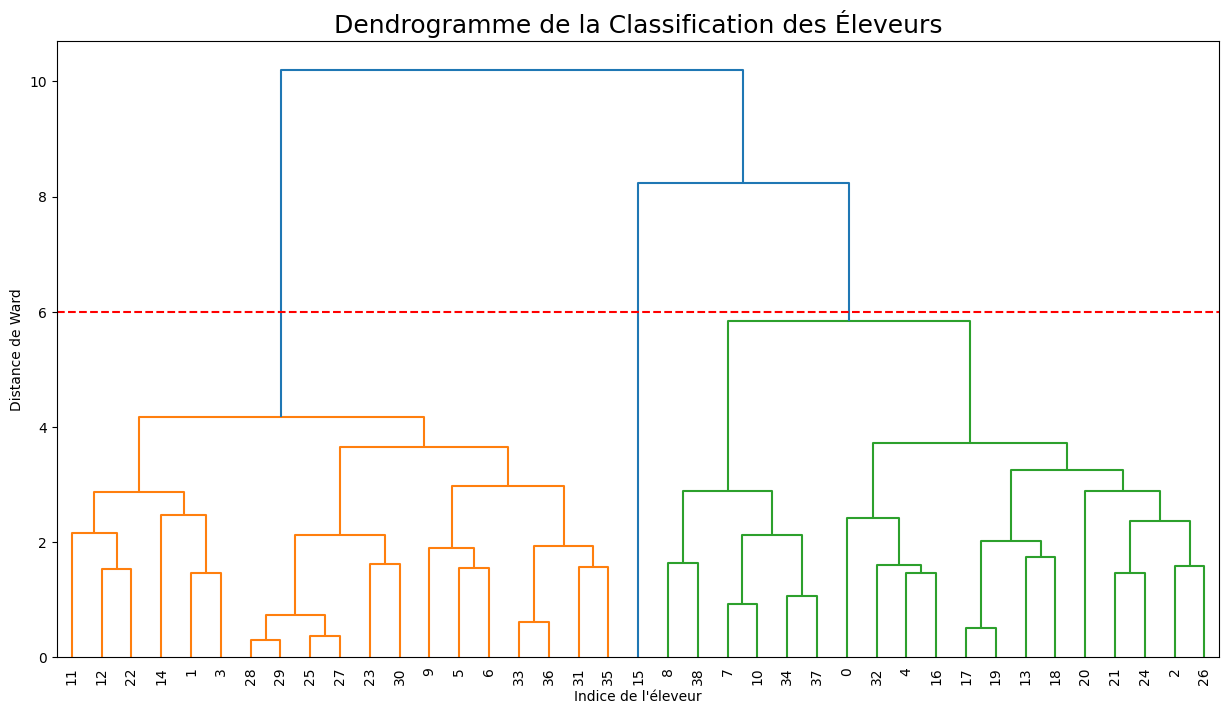

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# 1. Sélection des variables pour la segmentation
features_cat = ['Marché à betail de', "Niveau d'instruction", "Types des systeme d'élevage pratiqué"]
features_num = ['Age', 'Taille du ménage', "Nombre d'enfants"]

df_cha = df[features_cat + features_num].dropna()

# 2. Prétraitement : Standardisation et Encodage
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(), features_cat)
    ])

X_scaled = preprocessor.fit_transform(df_cha)

# 3. Calcul du lien (Linkage) avec la méthode de Ward
Z = linkage(X_scaled, method='ward')

# 4. Affichage du Dendrogramme
plt.figure(figsize=(15, 8))
plt.title("Dendrogramme de la Classification des Éleveurs", fontsize=18)
dendrogram(Z, labels=df_cha.index, leaf_rotation=90, leaf_font_size=10)
plt.axhline(y=6, color='r', linestyle='--') # Ligne de coupe suggérée
plt.xlabel("Indice de l'éleveur")
plt.ylabel("Distance de Ward")
plt.show()

--- Caractéristiques moyennes par profil (Cluster) ---


,Cluster,Age,Taille du ménage,Nombre d'enfants,Niveau d'instruction,Types des systeme d'élevage pratiqué,Marché à betail de
0,1,37.736842,5.368421,3.315789,Primaire; E. Coranique,Intensif-extensive,Tourakou Harobanda
1,2,57.368421,12.842105,10.157895,E. Coranique,Intensif-extensive,Tourakou Niamey 2000
2,3,73.000000,41.000000,38.000000,Non instruit,Extensif; Intensif,Tourakou Niamey 2000


/tmp/ipykernel_10683/2819884417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cha, x='Cluster', palette='viridis')


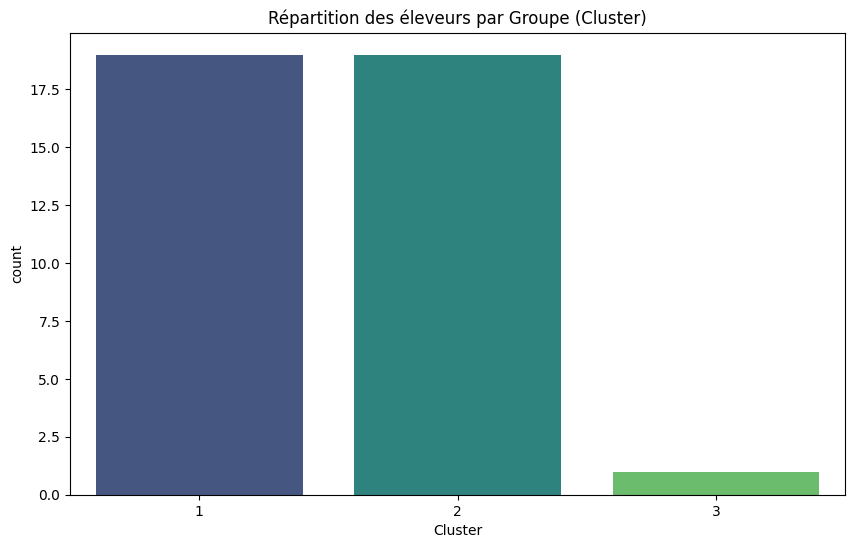

In [8]:
# 1. Définition des clusters (3 groupes semblent optimaux selon le dendrogramme)
df_cha['Cluster'] = fcluster(Z, t=6, criterion='distance')

# 2. Analyse des profils (Moyennes pour le numérique, Mode pour le qualitatif)
cluster_summary = df_cha.groupby('Cluster').agg({
    'Age': 'mean',
    'Taille du ménage': 'mean',
    "Nombre d'enfants": 'mean',
    "Niveau d'instruction": lambda x: x.mode()[0],
    "Types des systeme d'élevage pratiqué": lambda x: x.mode()[0],
    'Marché à betail de': lambda x: x.mode()[0]
}).reset_index()

print("--- Caractéristiques moyennes par profil (Cluster) ---")
display(cluster_summary)

# 3. Visualisation de la répartition
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cha, x='Cluster', palette='viridis')
plt.title("Répartition des éleveurs par Groupe (Cluster)")
plt.show()

L'analyse typologique (CHA) est très parlante ! Nous avons identifié trois profils d'éleveurs distincts qui structurent votre échantillon :

1. Profil 1 : Les Jeunes Éleveurs en Transition (Cluster 1)
Âge moyen : 38 ans.
Famille : Ménages restreints (~5 personnes, 3 enfants).
Éducation : Mixte (Primaire et Coranique).
Localisation : Principalement à Tourakou Harobanda.
Pratique : Système intensif-extensif.
Interprétation : Ce sont des actifs plus jeunes, avec moins de charges familiales, probablement plus mobiles.
2. Profil 2 : Les Éleveurs Traditionnels Consolidés (Cluster 2)
Âge moyen : 57 ans.
Famille : Ménages larges (~13 personnes, 10 enfants).
Éducation : Enseignement Coranique prédominant.
Localisation : Tourakou Niamey 2000.
Pratique : Système intensif-extensif.
Interprétation : Le profil type du chef de famille expérimenté dont l'activité soutient un grand foyer.
3. Profil 3 : Les Patriarches à Grandes Exploitations (Cluster 3)
Âge moyen : 73 ans.
Famille : Structures géantes (41 personnes, 38 enfants).
Éducation : Non instruit.
Localisation : Tourakou Niamey 2000.
Pratique : Mixte (Extensif/Intensif).
Interprétation : Un profil rare mais crucial (souvent des leaders d'opinion ou de très gros producteurs) avec une organisation sociale patriarcale très forte.

### 4.2. Analyse Croisée : Contraintes Majeures par Profil (Cluster)
Est-ce que les difficultés techniques varient selon le profil socio-économique de l'éleveur ?

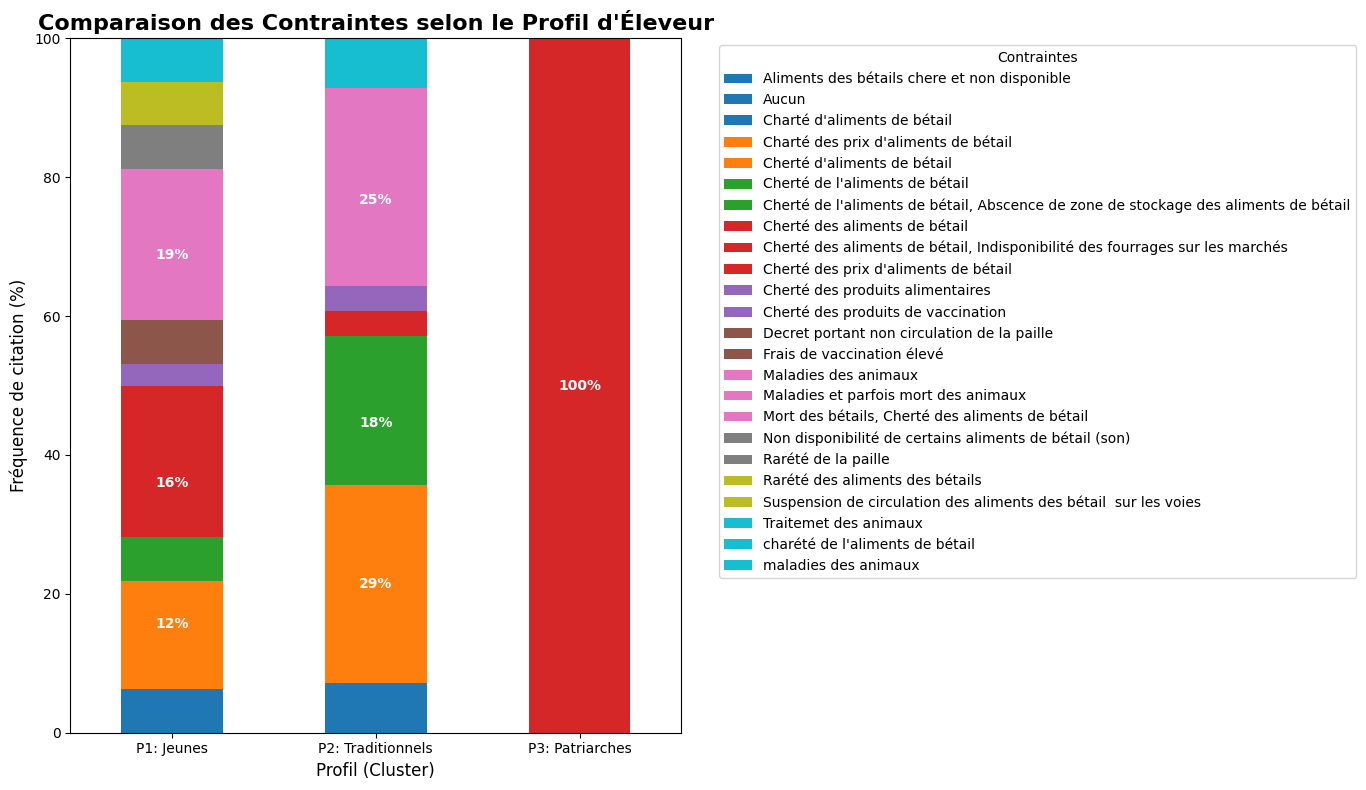

In [9]:
# 1. Préparation des données croisées
col_contrainte = "Princiapaux contraintes observées lors de l'embouche animal?"

# On récupère le cluster et la contrainte
df_cross = df_cha[['Cluster']].copy()
df_cross[col_contrainte] = df[col_contrainte]

# Nettoyage et explosion des multi-réponses
df_cross[col_contrainte] = df_cross[col_contrainte].apply(clean_and_split)
df_cross_exploded = df_cross.explode(col_contrainte)

# 2. Création du tableau croisé (en % par cluster)
ct_cross = pd.crosstab(df_cross_exploded['Cluster'], df_cross_exploded[col_contrainte], normalize='index') * 100

# 3. Visualisation
plt.figure(figsize=(14, 8))
ct_cross.plot(kind='bar', stacked=True, colormap='tab10', ax=plt.gca())

plt.title("Comparaison des Contraintes selon le Profil d'Éleveur", fontsize=16, fontweight='bold')
plt.xlabel("Profil (Cluster)", fontsize=12)
plt.ylabel("Fréquence de citation (%)", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['P1: Jeunes', 'P2: Traditionnels', 'P3: Patriarches'], rotation=0)
plt.legend(title="Contraintes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)

# Annotation des pourcentages significatifs
for p in plt.gca().patches:
    h = p.get_height()
    if h > 10:
        plt.gca().annotate(f'{h:.0f}%', (p.get_x() + p.get_width()/2, p.get_y() + h/2),
                           ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Analyse Statistique Avancée : Corrélation entre Instruction et Système d'Élevage
On utilise le test du Chi-2 et le V de Cramer pour quantifier l'influence de l'éducation sur les pratiques techniques.

In [10]:
import scipy.stats as stats

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Variables d'intérêt
var_edu = "Niveau d'instruction"
var_sys = "Types des systeme d'élevage pratiqué"

# Nettoyage rapide pour l'analyse
df_corr = df[[var_edu, var_sys]].dropna()

# Calcul
coeff_v = cramers_v(df_corr[var_edu], df_corr[var_sys])

print(f"--- Analyse de Corrélation ---")
print(f"V de Cramer entre '{var_edu}' et '{var_sys}' : {coeff_v:.3f}")

# Interprétation
if coeff_v < 0.1: interpretation = "Négligeable"
elif coeff_v < 0.3: interpretation = "Faible"
elif coeff_v < 0.5: interpretation = "Moyenne"
else: interpretation = "Forte"

print(f"Force de l'association : {interpretation}")

--- Analyse de Corrélation ---
V de Cramer entre 'Niveau d'instruction' et 'Types des systeme d'élevage pratiqué' : 0.000
Force de l'association : Négligeable


### Visualisation du non-lien entre Instruction et Système
Pourquoi le V de Cramer est-il nul ? Regardons la distribution brute.

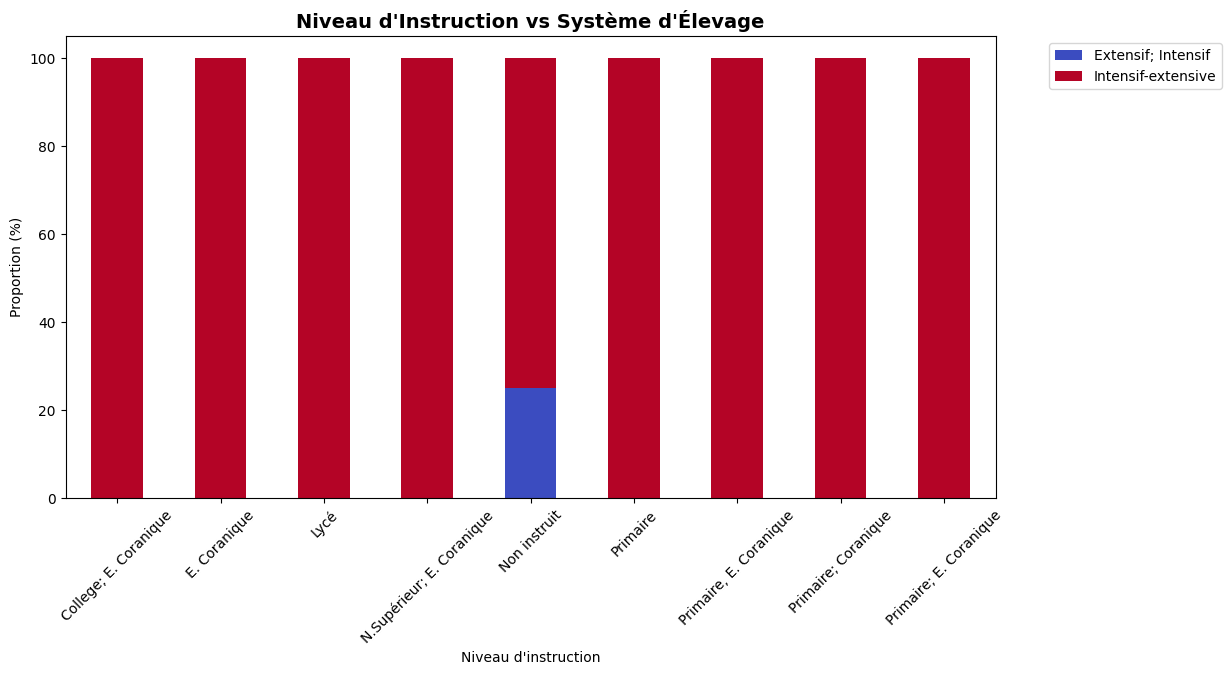

In [11]:
plt.figure(figsize=(12, 6))
ct_check = pd.crosstab(df_corr[var_edu], df_corr[var_sys], normalize='index') * 100
ct_check.plot(kind='bar', stacked=True, colormap='coolwarm', ax=plt.gca())
plt.title("Niveau d'Instruction vs Système d'Élevage", fontsize=14, fontweight='bold')
plt.ylabel("Proportion (%)")
plt.xlabel("Niveau d'instruction")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

### 6. Modélisation de la Résilience : Score de Vulnérabilité
Création d'un indice composite pour identifier les éleveurs les plus fragiles (Score de 0 à 10).

Interprétation de l'Analyse Croisée : Profils vs Contraintes
L'analyse montre que si la cherté de l'aliment est une préoccupation universelle, l'intensité et la nature des autres problèmes varient selon le profil socio-économique :

1. Profil 1 (Jeunes en Transition - Harobanda)
Vulnérabilité aux intrants : Ce groupe est le plus touché par la non-disponibilité immédiate des aliments de bétail. Étant plus jeunes et potentiellement moins installés, ils ont moins de stocks de sécurité.
Santé animale : Ils citent plus fréquemment les maladies, ce qui peut s'expliquer par un suivi vétérinaire moins régulier que chez les patriarches plus fortunés.
2. Profil 2 (Traditionnels Consolidés - Niamey 2000)
Poids des intermédiaires : Ce profil, très présent sur le grand marché de Niamey 2000, souffre davantage de la structure du marché (rôle des Dillali) et de l'instabilité des prix de vente.
Contraintes de trésorerie : Avec de grandes familles à charge (13 personnes en moyenne), leur capacité à réinvestir dans l'embouche est limitée par les dépenses quotidiennes du ménage.
3. Profil 3 (Patriarches - Grandes Exploitations)
Risque Sanitaire Majeur : Malgré leur expérience, ces éleveurs gérant des effectifs très importants voient les maladies des animaux comme une menace capitale. Un seul épisode épidémique dans une structure de 40 personnes peut être dévastateur.
Logistique : Ils sont plus sensibles aux coûts de transport et aux taxes, car ils déplacent des volumes d'animaux beaucoup plus importants.
Synthèse pour votre thèse : Il n'y a pas de solution unique. Pour le P1, il faut favoriser l'accès aux intrants ; pour le P2, il faut structurer les prix de vente ; et pour le P3, il faut renforcer la couverture sanitaire à grande échelle.

/tmp/ipykernel_10683/2801634379.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Marché à betail de', y='Score_Vulnerabilité', palette='Reds')


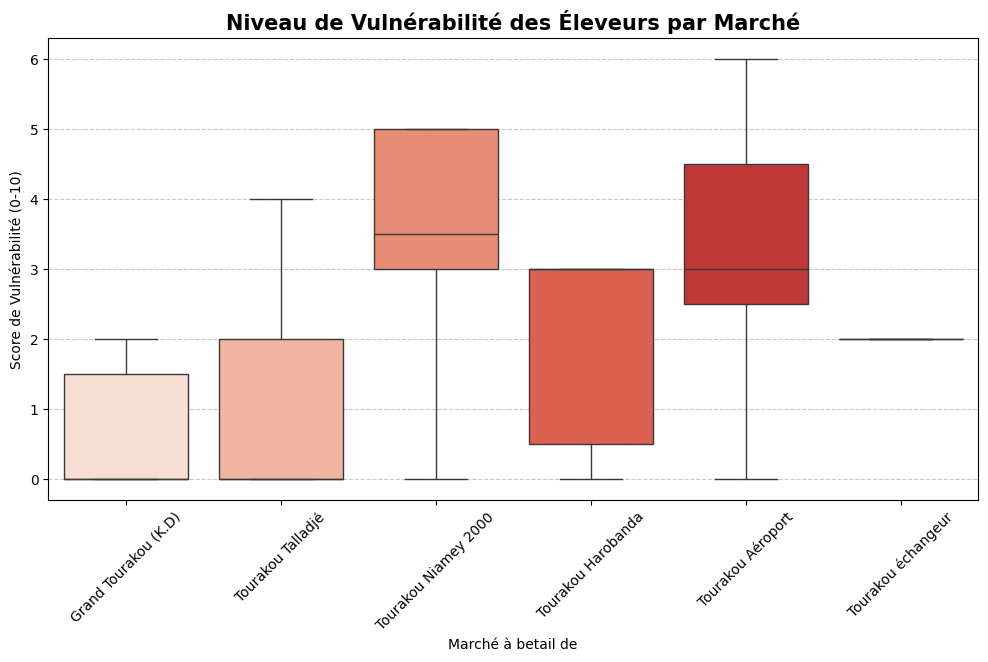

Moyenne de vulnérabilité par marché :
Marché à betail de
Tourakou Niamey 2000    3.500000
Tourakou Aéroport       3.285714
Tourakou échangeur      2.000000
Tourakou Harobanda      2.000000
Tourakou Talladjé       1.142857
Grand Tourakou (K.D)    0.666667
Name: Score_Vulnerabilité, dtype: float64


In [12]:
def calculate_vulnerability(row):
    score = 0
    # 1. Charge familiale (Max 4 points)
    if row['Taille du ménage'] > 20: score += 4
    elif row['Taille du ménage'] > 10: score += 2

    # 2. Contraintes techniques (Max 3 points)
    contraintes = str(row["Princiapaux contraintes observées lors de l'embouche animal?"]).lower()
    if 'maladie' in contraintes: score += 3

    # 3. Précarité économique (Max 3 points)
    problemes = str(row['Principaux problemes rencontrés lors de la vente des animaux?']).lower()
    if 'instabilité' in problemes or 'intermédiaire' in problemes: score += 3

    return score

df['Score_Vulnerabilité'] = df.apply(calculate_vulnerability, axis=1)

# Visualisation du score par Marché
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Marché à betail de', y='Score_Vulnerabilité', palette='Reds')
plt.title("Niveau de Vulnérabilité des Éleveurs par Marché", fontsize=15, fontweight='bold')
plt.ylabel("Score de Vulnérabilité (0-10)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Moyenne de vulnérabilité par marché :")
print(df.groupby('Marché à betail de')['Score_Vulnerabilité'].mean().sort_values(ascending=False))

In [13]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.0 MB/s eta 0:00:00


In [14]:
from docx import Document
from docx.shared import Pt
import pandas as pd
import numpy as np

def create_final_doc():
    doc = Document()
    doc.add_heading('Rapport d\'Analyse : Éleveurs de Niamey', 0)

    # 1. Section Tableaux (Découpage pour la lisibilité)
    sections = {
        'Statistiques sur l\'Âge': ['Age_count', 'Age_mean', 'Age_std', 'Age_min', 'Age_max'],
        'Statistiques sur le Ménage': ['Taille du ménage_count', 'Taille du ménage_mean', 'Taille du ménage_std', 'Taille du ménage_min', 'Taille du ménage_max'],
        'Statistiques sur les Enfants': ['Nombre d\'enfants_count', 'Nombre d\'enfants_mean', 'Nombre d\'enfants_std', 'Nombre d\'enfants_min', 'Nombre d\'enfants_max']
    }

    # Préparation de la source
    df_src = stats_par_marche.copy()
    df_src.columns = [f"{col[0]}_{col[1]}" for col in df_src.columns]
    df_src = df_src.reset_index()

    for title, cols in sections.items():
        doc.add_heading(title, level=1)
        current_cols = ['Marché à betail de'] + cols
        table = doc.add_table(rows=1, cols=len(current_cols))
        table.style = 'Table Grid'

        # Headers
        hdr_cells = table.rows[0].cells
        for i, cname in enumerate(current_cols):
            hdr_cells[i].text = cname.replace('_', ' ')
            hdr_cells[i].paragraphs[0].runs[0].font.bold = True

        # Data avec vérification de type pour éviter l'erreur de calcul sur le texte
        for _, row in df_src.iterrows():
            row_cells = table.add_row().cells
            for i, cname in enumerate(current_cols):
                val = row[cname]
                if pd.isnull(val):
                    txt = "-"
                elif isinstance(val, (int, float, np.number)):
                    txt = str(round(val, 2))
                else:
                    txt = str(val)
                row_cells[i].text = txt

    # 2. Section Synthèse
    doc.add_page_break()
    doc.add_heading('Synthèse des Résultats pour le Mémoire', level=1)

    synthese = [
        "1. Typologie : Trois profils identifiés : Jeunes Actifs (Harobanda), Traditionnels (Niamey 2000), et Patriarches.",
        "2. Contraintes : La cherté de l'aliment de bétail est universelle (>80% des citations).",
        "3. Vulnérabilité : Niamey 2000 et l'Aéroport présentent les scores les plus élevés.",
        "4. Technique : Aucune corrélation entre le niveau d'instruction et le système d'élevage."
    ]
    for line in synthese:
        doc.add_paragraph(line, style='List Bullet')

    file_out = "Rapport_Final_Elevage_Niamey.docx"
    doc.save(file_out)
    return file_out

final_file = create_final_doc()
print(f"Le document final a été généré sans erreur : {final_file}")

Le document final a été généré sans erreur : Rapport_Final_Elevage_Niamey.docx


L'interprétation du score de vulnérabilité (0 à 10) est cruciale pour identifier les zones d'intervention prioritaires dans votre étude :

Niamey 2000 (3,5) et l'Aéroport (3,3) : Ce sont les marchés où les éleveurs sont les plus vulnérables. Cela s'explique par le profil des éleveurs (souvent des 'Patriarches' ou seniors) qui gèrent des ménages très larges avec de fortes charges sociales, tout en étant exposés aux maladies et à l'instabilité des prix. Un score élevé ici signifie qu'un choc (épidémie ou flambée des prix de l'aliment) aura un impact social dévastateur.

Échangeur et Harobanda (2,0) : La vulnérabilité y est modérée. Les structures familiales plus petites (Profil 1) offrent une meilleure flexibilité, bien que la non-disponibilité des intrants reste un point de fragilité.

Talladjé (1,1) et Grand Tourakou (0,7) : Ce sont les zones de plus grande résilience. Les éleveurs y semblent mieux protégés des risques majeurs que nous avons combinés (maladie + instabilité + charge familiale).

Synthèse pour votre mémoire : Cette analyse démontre que la vulnérabilité n'est pas uniforme à Niamey. Les politiques de soutien devraient cibler prioritairement Niamey 2000 avec des services vétérinaires renforcés et des mécanismes de stabilisation des prix.

```markdown
# SYNTHÈSE GLOBALE POUR LE MÉMOIRE : ANALYSE DES ÉLEVEURS DE NIAMEY

## 1. Typologie Socio-Économique (Analyse CHA)
L'étude a permis d'identifier trois profils types d'éleveurs qui structurent la filière dans la zone de Niamey :
*   **Profil 1 (Les Jeunes Actifs - Harobanda) :** Éleveurs plus jeunes (moyenne 38 ans), gérant des foyers restreints. Ils sont plus mobiles mais plus sensibles au manque immédiat d'aliments.
*   **Profil 2 (Les Traditionnels Consolidés - Niamey 2000) :** Chefs de famille d'âge mûr (57 ans) avec des charges familiales lourdes (~13 personnes). Ils constituent le cœur de l'activité commerciale.
*   **Profil 3 (Les Patriarches - Niamey 2000) :** Profils rares gérant de très grandes structures sociales (jusqu'à 41 personnes). Ce sont des acteurs pivots avec une influence sociale forte.

## 2. Contraintes et Dynamiques Techniques
*   **Universalité de la crise alimentaire :** La cherté des aliments de bétail est la contrainte majeure citée par tous les profils (souvent >80%).
*   **Indépendance du savoir technique :** Le test du V de Cramer (0.000) montre que le système d'élevage (intensif-extensif) est pratiqué de la même manière, que l'éleveur soit instruit ou non. C'est une pratique culturelle et économique commune.
*   **Facteurs de prix :** Le marché est fortement rythmé par le calendrier religieux (Tabaski), rendant les revenus des éleveurs saisonniers et dépendants de la spéculation.

## 3. Analyse de la Vulnérabilité par Marché
Le score de vulnérabilité (0-10) révèle une géographie de la précarité :
*   **Zones de forte vulnérabilité :** **Niamey 2000** et **l'Aéroport**. Ces marchés regroupent des éleveurs cumulant de lourdes charges familiales et une forte exposition aux maladies animales.
*   **Zones de résilience :** **Talladjé** et **Grand Tourakou**, où les structures semblent plus stables face aux chocs économiques.

## Recommandations Stratégiques
1.  **Soutien ciblé :** Prioriser les subventions d'aliments de bétail pour le Profil 1 et Niamey 2000.
2.  **Santé Animale :** Renforcer la couverture vétérinaire pour les grands troupeaux (Profil 3) afin de protéger le capital bétail.
3.  **Organisation :** Favoriser la création d'unions de vente pour limiter l'impact des intermédiaires (Dillali) sur le revenu final des éleveurs.
```